# lev008 — process & cut segmentation

Segments `data/Hermle/20260630/axon_logger_ptw_lev008.raw.json` (2 GB, ~7275 records) into
per-process and per-cut force and machine-state DataFrames.

**Approach**
- Memory-safe streaming JSON parse (line-based, no full load) — keeps only `force` and `machine` records.
- Checkpoint to parquet after the initial parse; all segmentation work reads from parquet.
- Cut detection from per-block force AC-RMS (channels 0+1 union, threshold 50 counts).
- Process detection from `programrunning` NC-state flag rising/falling edges.
- Outputs: `force_lev008.parquet`, `machine_lev008.parquet`, `lev008_cut_summary.parquet/.csv`,
  `lev008_cuts.parquet`, `lev008_processes.parquet` — all under `data/converted/20260630/`.

**Validated assumptions**
- fs = 20 000 Hz for force (20 000 samples/block = 1 s/block, confirmed from inter-block delta distribution).
- Machine sample rate = 250 Hz (250 samples/1-s block).
- Block `time` field marks block-end (not start).
- `force_2` has an elevated mechanical-noise baseline and is excluded from cut-detection thresholding
  (still included in the output parquet).

In [1]:
import json
import time as time_mod
from collections import defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import psutil
import pyarrow.parquet as pq

proc = psutil.Process()
def mem_mb(): return proc.memory_info().rss / 1e6

print(f"pandas {pd.__version__}, numpy {np.__version__}")

pandas 3.0.3, numpy 2.4.6


In [2]:
JSON_PATH  = Path(r"C:\Users\thmru\github\2026_EstanciaInvestigacion_PTW\data\Hermle\20260630\axon_logger_ptw_lev008.raw.json")
OUTPUT_DIR = Path(r"C:\Users\thmru\github\2026_EstanciaInvestigacion_PTW\data\converted\20260630")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ── segmentation parameters (validated via diagnostic exploration) ────────────
FS_FORCE        = 20_000   # Hz — validated: 1-s block = 20 000 samples
FS_MACHINE      = 250      # Hz — inferred: 250 samples / 1-s block
IDLE_THRESH     = 50.0     # AC-RMS counts: below = idle, above = cutting
MAX_INTRA_GAP_S = 3.0      # max within-cut idle gap (s)
MIN_CUT_S       = 3.0      # minimum cut duration (s)
EXPT_START      = pd.Timestamp("2026-06-30 09:00:00", tz="UTC")  # pre-test data cutoff

KEEP_SENSORTYPES = {"force", "machine"}

print("Paths and parameters set.")

Paths and parameters set.


## Parsing functions (reused from `axon_logger_json2df.ipynb`)

In [3]:
def extract_block_meta(record: dict) -> dict:
    if record["spindleidx"] != 0:
        raise ValueError(f"record {record['_id']['$oid']}: unexpected spindleidx={record['spindleidx']}")
    wp = record["workpiecedata"][0]
    serialnr_parts = tuple(int(s["$numberLong"]) for s in wp["serialnr"])
    return {
        "id":         record["_id"]["$oid"],
        "time":       pd.Timestamp(record["time"]["$date"]),
        "process":    record["process"],
        "sensortype": record["sensortype"],
        "sensoridx":  record["sensoridx"],
        "materialnr": int(wp["materialnr"]["$numberLong"]),
        "batchnr":    int(wp["batchnr"]["$numberLong"]),
        "serialnr":   "-".join(str(s["$numberLong"]) for s in wp["serialnr"]),
        "serialnr_3": serialnr_parts[3] if len(serialnr_parts) > 3 else None,
    }


def build_waveform_df(items: list) -> pd.DataFrame:
    sample_len = len(items[0][1])
    width = len(str(sample_len - 1))
    sample_cols = [f"s{i:0{width}d}" for i in range(sample_len)]
    meta_rows, data_matrix = [], np.empty((len(items), sample_len))
    for block_idx, (meta, data) in enumerate(items):
        if len(data) != sample_len:
            raise ValueError(f"block {block_idx} ({meta['id']}): len {len(data)} != {sample_len}")
        data_matrix[block_idx] = data
        meta_rows.append({**meta, "block_idx": block_idx})
    return pd.concat([pd.DataFrame(meta_rows),
                      pd.DataFrame(data_matrix, columns=sample_cols)], axis=1)


def _unwrap_number(value):
    if isinstance(value, dict) and len(value) == 1:
        key, raw = next(iter(value.items()))
        if key == "$numberDouble":            return float(raw)
        if key in ("$numberLong", "$numberInt"): return int(raw)
    return value


def flatten_machine_sample(sample: dict) -> dict:
    flat = {}
    for ai, axis in enumerate(sample["axes"]):
        for field, value in axis.items():
            flat[f"axis{ai}_{field}"] = _unwrap_number(value)
    for i, v in enumerate(sample["io"]):          flat[f"io_{i}"] = _unwrap_number(v)
    for i, v in enumerate(sample["toolclamping"]): flat[f"toolclamping_{i}"] = _unwrap_number(v)
    for i, v in enumerate(sample["toollife"]):     flat[f"toollife_{i}"] = int(v["$numberLong"])
    flat["mc_materialnr"] = int(sample["materialnr"]["$numberLong"])
    flat["mc_batchnr"]    = int(sample["batchnr"]["$numberLong"])
    flat["mc_serialnr"]   = "-".join(str(s["$numberLong"]) for s in sample["serialnr"])
    skip = {"axes","io","toolclamping","toollife","materialnr","batchnr","serialnr"}
    for key, value in sample.items():
        if key not in skip:
            flat[key] = _unwrap_number(value)
    return flat


def build_machine_df(items: list) -> pd.DataFrame:
    rows = []
    for block_idx, (meta, data) in enumerate(items):
        for sample_idx, sample in enumerate(data):
            rows.append({**meta, "block_idx": block_idx, "sample_idx": sample_idx,
                         **flatten_machine_sample(sample)})
    return pd.DataFrame(rows)


print("Parsing functions defined.")

Parsing functions defined.


## 1 · Memory-safe streaming parse → checkpoint parquets

Record boundaries are detected by line prefix (validated against this specific file's consistent
2-space pretty-printing): every top-level record's outer braces sit at column 0.  
Skips all `acceleration` and `distance` records without parsing their data arrays.

> **Re-run note**: if the checkpoint files already exist, skip this cell and go to *Load from checkpoint*.

In [4]:
def iter_records_filtered(path, keep_sensortypes):
    """Stream pretty-printed JSON array; yield only records whose sensortype is kept."""
    buf = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            stripped = line.rstrip("\n")
            if stripped in ("{", "[{"):
                buf = [stripped[1:] if stripped.startswith("[") else stripped]
                continue
            if stripped in ("},", "}]"):
                buf.append("}")
                record = json.loads("\n".join(buf))
                buf = []
                if record["sensortype"] in keep_sensortypes:
                    yield record
                continue
            buf.append(stripped)


t0 = time_mod.time()
print(f"start mem={mem_mb():.0f} MB")

groups = defaultdict(list)
n = 0
for rec in iter_records_filtered(JSON_PATH, KEEP_SENSORTYPES):
    meta = extract_block_meta(rec)
    key  = f"{meta['sensortype']}_{meta['sensoridx']}"
    groups[key].append((meta, rec["data"]))
    n += 1
    if n % 500 == 0:
        print(f"  {n} kept records, mem={mem_mb():.0f} MB, elapsed={time_mod.time()-t0:.0f}s")

print(f"\ndone: {n} kept records, mem={mem_mb():.0f} MB, elapsed={time_mod.time()-t0:.0f}s")
for k in sorted(groups): print(f"  {k}: {len(groups[k])} blocks")

start mem=159 MB
  500 kept records, mem=559 MB, elapsed=7s
  1000 kept records, mem=1057 MB, elapsed=14s
  1500 kept records, mem=1525 MB, elapsed=22s
  2000 kept records, mem=2074 MB, elapsed=29s
  2500 kept records, mem=2627 MB, elapsed=37s
  3000 kept records, mem=3155 MB, elapsed=45s

done: 3009 kept records, mem=3166 MB, elapsed=45s
  force_0: 742 blocks
  force_1: 752 blocks
  force_2: 762 blocks
  machine_0: 753 blocks


In [5]:
# sort by time, build DataFrames, checkpoint
for items in groups.values():
    items.sort(key=lambda item: item[0]["time"])

for name in ["force_0", "force_1", "force_2"]:
    df = build_waveform_df(groups[name])
    out = OUTPUT_DIR / f"{name}_lev008_raw.parquet"
    df.to_parquet(out, index=False)
    print(f"  {name}: {df.shape} -> {out.name}")
    del df

machine_df = build_machine_df(groups["machine_0"])
out = OUTPUT_DIR / "machine_0_lev008_raw.parquet"
machine_df.to_parquet(out, index=False)
print(f"  machine_0: {machine_df.shape} -> {out.name}")
del machine_df, groups

print(f"\nTotal elapsed={time_mod.time()-t0:.0f}s")

  force_0: (742, 20010) -> force_0_lev008_raw.parquet
  force_1: (752, 20010) -> force_1_lev008_raw.parquet
  force_2: (762, 20010) -> force_2_lev008_raw.parquet
  machine_0: (188250, 171) -> machine_0_lev008_raw.parquet

Total elapsed=68s


## 2 · Load from checkpoint (start here on re-runs)

In [6]:
def load_ac_rms(fname):
    """Load force parquet, compute per-block AC-RMS, return lightweight metadata DataFrame."""
    df = pd.read_parquet(OUTPUT_DIR / fname)
    sc = sorted([c for c in df.columns if c.startswith("s") and c[1:].isdigit()])
    df = df.sort_values("time").reset_index(drop=True)
    d  = df[sc].to_numpy(dtype=np.float64)
    ac = np.sqrt(np.mean((d - d.mean(axis=1, keepdims=True))**2, axis=1))
    return df[["time","block_idx","serialnr_3","sensoridx"]].assign(ac_rms=ac)


b0 = load_ac_rms("force_0_lev008_raw.parquet")
b1 = load_ac_rms("force_1_lev008_raw.parquet")
# force_2 loaded for output only; excluded from thresholding (elevated mechanical-noise baseline)

mdf_cols_want = ["id","time","block_idx","sample_idx","programrunning","ncstop",
                 "programstopped","serialnr_3",
                 "axis0_speedorfeedact","axis1_speedorfeedact","axis2_speedorfeedact",
                 "axis3_speedorfeedact","axis4_speedorfeedact",
                 "axis0_loadact","axis1_loadact","axis2_loadact",
                 "axis3_loadact","axis4_loadact",
                 "toolintnr","toolradius","toollength","toolteethnr",
                 "axis0_temperature","axis1_temperature","axis2_temperature"]
all_machine_cols = pq.read_schema(OUTPUT_DIR / "machine_0_lev008_raw.parquet").names
mdf_cols = [c for c in mdf_cols_want if c in all_machine_cols]
mdf = pd.read_parquet(OUTPUT_DIR / "machine_0_lev008_raw.parquet", columns=mdf_cols)
mdf = mdf.sort_values(["block_idx","sample_idx"]).reset_index(drop=True)

print(f"force_0: {len(b0)} blocks  |  force_1: {len(b1)} blocks")
print(f"machine_0: {len(mdf)} samples, {mdf['block_idx'].nunique()} blocks")

force_0: 742 blocks  |  force_1: 752 blocks
machine_0: 188250 samples, 753 blocks


## 3 · Time-axis diagnostics

In [7]:
for name, b in [("force_0", b0), ("force_1", b1)]:
    deltas = b["time"].sort_values().diff().dt.total_seconds().dropna()
    print(f"{name}: median gap={deltas.median():.2f}s, gaps>5s: {(deltas>5).sum()}")

# Conclusion: median inter-block delta = 1.0 s  →  block duration = 1 s  →  fs = 20 000 Hz
# block `time` marks block-END; sample timestamps can be reconstructed as
#   t_sample_k = block_time - (sample_len - 1 - k) / fs
print("\nValidated: fs_force=20000 Hz, block_duration=1 s, time=block-END marker")

force_0: median gap=1.00s, gaps>5s: 146
force_1: median gap=1.00s, gaps>5s: 152

Validated: fs_force=20000 Hz, block_duration=1 s, time=block-END marker


## 4 · Cut detection — force_0 + force_1 union

`force_2` is excluded from thresholding because it shows an elevated mechanical-noise baseline
during the experimental window, producing false active indicators between genuine cutting events.
It is still included unchanged in the output force parquet.

In [8]:
# restrict to experimental window (drop pre-test data recorded on June 29)
b0e = b0[b0.time >= EXPT_START].reset_index(drop=True)
b1e = b1[b1.time >= EXPT_START].reset_index(drop=True)

s0 = b0e.set_index(b0e["time"].dt.round("1s"))["ac_rms"].rename("f0")
s1 = b1e.set_index(b1e["time"].dt.round("1s"))["ac_rms"].rename("f1")
# use .join() to avoid Pandas4Warning about implicit DatetimeIndex sorting in concat
combined = s0.to_frame().join(s1.to_frame(), how="outer").sort_index()
combined["any_active"] = (combined[["f0","f1"]] > IDLE_THRESH).any(axis=1)
combined["max_ac"]     = combined[["f0","f1"]].max(axis=1)

active = combined[combined["any_active"]].copy()
active["gap_from_prev"] = active.index.to_series().diff().dt.total_seconds().fillna(9999)
active["cut_label"]     = (active["gap_from_prev"] > MAX_INTRA_GAP_S).cumsum()

cuts_raw = []
for label, grp in active.groupby("cut_label"):
    t_start = grp.index.min() - pd.Timedelta(seconds=1)
    t_end   = grp.index.max()
    dur = (t_end - t_start).total_seconds()
    if dur < MIN_CUT_S:
        continue
    cuts_raw.append({
        "cut_id":          len(cuts_raw),
        "cut_start":       t_start,
        "cut_end":         t_end,
        "duration_s":      dur,
        "n_active_blocks": len(grp),
        "peak_max_ac":     float(grp["max_ac"].max()),
        "mean_max_ac":     float(grp["max_ac"].mean()),
    })

cuts_df = pd.DataFrame(cuts_raw)
print(f"Cuts detected: {len(cuts_df)}  (threshold={IDLE_THRESH} counts AC-RMS)")
print(cuts_df[["cut_id","cut_start","cut_end","duration_s","n_active_blocks","peak_max_ac"]])

Cuts detected: 29  (threshold=50.0 counts AC-RMS)
    cut_id                 cut_start                   cut_end  duration_s  \
0        0 2026-06-30 09:21:08+00:00 2026-06-30 09:21:16+00:00         8.0   
1        1 2026-06-30 11:01:27+00:00 2026-06-30 11:01:37+00:00        10.0   
2        2 2026-06-30 11:03:45+00:00 2026-06-30 11:03:59+00:00        14.0   
3        3 2026-06-30 11:04:47+00:00 2026-06-30 11:04:50+00:00         3.0   
4        4 2026-06-30 11:05:00+00:00 2026-06-30 11:05:09+00:00         9.0   
5        5 2026-06-30 11:11:08+00:00 2026-06-30 11:11:18+00:00        10.0   
6        6 2026-06-30 11:13:40+00:00 2026-06-30 11:13:50+00:00        10.0   
7        7 2026-06-30 11:14:29+00:00 2026-06-30 11:14:40+00:00        11.0   
8        8 2026-06-30 11:22:39+00:00 2026-06-30 11:22:43+00:00         4.0   
9        9 2026-06-30 11:23:39+00:00 2026-06-30 11:23:43+00:00         4.0   
10      10 2026-06-30 11:24:13+00:00 2026-06-30 11:24:23+00:00        10.0   
11      11 202

## 5 · Process detection — `programrunning` NC-flag transitions

In [9]:
mblock = (mdf.groupby("block_idx")[["time","programrunning","ncstop","programstopped","serialnr_3"]]
          .agg({"time":"first","programrunning":"any","ncstop":"any",
                "programstopped":"any","serialnr_3":"first"})
          .reset_index().sort_values("time").reset_index(drop=True))

mblock["prog_edge"] = mblock["programrunning"].astype(int).diff().fillna(0)
starts_t = mblock.loc[mblock["prog_edge"] ==  1, "time"].tolist()
ends_t   = mblock.loc[mblock["prog_edge"] == -1, "time"].tolist()

proc_rows, used_end_idx = [], -1
for ts in starts_t:
    valid_ends = [(i, e) for i, e in enumerate(ends_t) if e > ts and i > used_end_idx]
    used_ei, te = valid_ends[0] if valid_ends else (len(ends_t)-1, mblock["time"].max())
    used_end_idx = used_ei
    dur = (te - ts).total_seconds()
    if dur > 10:
        proc_rows.append({"process_id": len(proc_rows), "process_start": ts,
                           "process_end": te, "duration_s": dur})

processes_df = pd.DataFrame(proc_rows)
print(f"Processes detected: {len(processes_df)}")
print(processes_df[["process_id","process_start","process_end","duration_s"]].to_string())

Processes detected: 9
   process_id                    process_start                      process_end  duration_s
0           0 2026-06-30 09:13:50.049000+00:00 2026-06-30 09:16:58.049000+00:00       188.0
1           1 2026-06-30 09:16:59.049000+00:00 2026-06-30 09:25:03.049000+00:00       484.0
2           2 2026-06-30 11:00:07.049000+00:00 2026-06-30 11:02:29.049000+00:00       142.0
3           3 2026-06-30 11:02:35.049000+00:00 2026-06-30 11:13:00.049000+00:00       625.0
4           4 2026-06-30 11:13:41.049000+00:00 2026-06-30 11:15:00.049000+00:00        79.0
5           5 2026-06-30 11:22:37.049000+00:00 2026-06-30 11:33:46.049000+00:00       669.0
6           6 2026-06-30 11:34:45.049000+00:00 2026-06-30 11:43:46.049000+00:00       541.0
7           7 2026-06-30 11:43:54.049000+00:00 2026-06-30 11:56:25.049000+00:00       751.0
8           8 2026-06-30 12:05:50.049000+00:00 2026-06-30 12:19:26.049000+00:00       816.0


## 6 · Assign cuts → processes · QA plot

In [10]:
cuts_df["process_id"] = -1
for _, proc in processes_df.iterrows():
    mask = ((cuts_df["cut_start"] >= proc["process_start"] - pd.Timedelta(seconds=10)) &
            (cuts_df["cut_end"]   <= proc["process_end"]   + pd.Timedelta(seconds=10)))
    cuts_df.loc[mask, "process_id"] = int(proc["process_id"])

cuts_df["cut_id_within_process"] = (
    cuts_df.groupby("process_id").cumcount().where(cuts_df["process_id"] >= 0, -1)
)

print("Cuts per process:")
print(cuts_df.groupby("process_id")["cut_id"].count())
print(f"\nAssigned: {(cuts_df.process_id>=0).sum()} / {len(cuts_df)} cuts")
print(f"Note: {len(processes_df)} NC-program intervals detected (user expected 8 processes).")
print("  Light cuts below threshold=50 AC-RMS counts are not detectable from force signal alone.")

Cuts per process:
process_id
1    1
2    1
3    4
4    2
5    7
6    1
7    6
8    7
Name: cut_id, dtype: int64

Assigned: 29 / 29 cuts
Note: 9 NC-program intervals detected (user expected 8 processes).
  Light cuts below threshold=50 AC-RMS counts are not detectable from force signal alone.


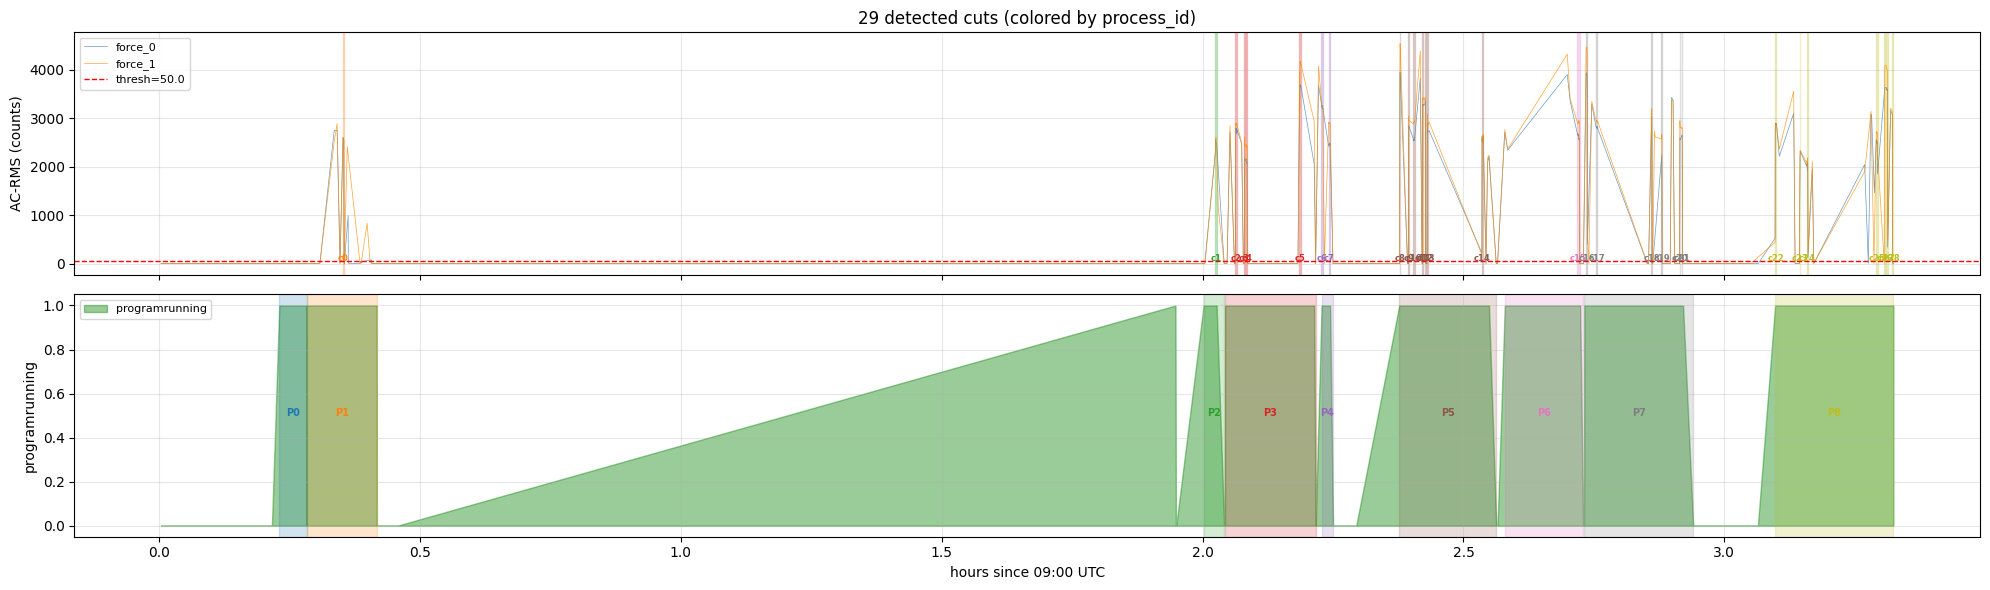

QA plot saved.


In [11]:
t_ref   = EXPT_START
colors  = plt.cm.tab10.colors
hours_m = (mblock.loc[mblock.time >= t_ref, "time"] - t_ref).dt.total_seconds() / 3600
prog_m  = mblock.loc[mblock.time >= t_ref, "programrunning"].astype(int)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(20, 6), sharex=True)

for bdf, col, lbl in [(b0e, "steelblue", "force_0"), (b1e, "darkorange", "force_1")]:
    h = (bdf["time"].dt.round("1s") - t_ref).dt.total_seconds() / 3600
    ax1.plot(h, bdf["ac_rms"].values, lw=0.5, color=col, label=lbl, alpha=0.8)
ax1.axhline(IDLE_THRESH, color="red", ls="--", lw=1, label=f"thresh={IDLE_THRESH}")
for _, row in cuts_df.iterrows():
    ts = (row.cut_start - t_ref).total_seconds() / 3600
    te = (row.cut_end   - t_ref).total_seconds() / 3600
    pid = int(row.process_id)
    c   = colors[pid % 10] if pid >= 0 else "gray"
    ax1.axvspan(ts, te, alpha=0.25, color=c)
    ax1.text((ts+te)/2, IDLE_THRESH*1.15, f"c{int(row.cut_id)}",
             fontsize=6, ha="center", color=c, fontweight="bold")
ax1.set_ylabel("AC-RMS (counts)")
ax1.set_title(f"{len(cuts_df)} detected cuts (colored by process_id)")
ax1.legend(fontsize=8, loc="upper left")
ax1.grid(True, alpha=0.3)

ax2.fill_between(hours_m, prog_m, alpha=0.4, color="green", label="programrunning")
for _, proc in processes_df.iterrows():
    ts = (proc.process_start - t_ref).total_seconds() / 3600
    te = (proc.process_end   - t_ref).total_seconds() / 3600
    c  = colors[int(proc.process_id) % 10]
    ax2.axvspan(ts, te, alpha=0.2, color=c)
    ax2.text((ts+te)/2, 0.5, f"P{proc.process_id}", fontsize=7, ha="center",
             color=c, fontweight="bold")
ax2.set_ylabel("programrunning")
ax2.set_xlabel("hours since 09:00 UTC")
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "lev008_final_segmentation.png", dpi=120, bbox_inches="tight")
plt.show()
print("QA plot saved.")

## 7 · Assign `process_id` / `cut_id` to force blocks

In [12]:
# build fast lookup: block timestamp → (process_id, cut_id, cut_id_within_process)
_intervals = list(cuts_df[["cut_start","cut_end","process_id",
                             "cut_id","cut_id_within_process"]].itertuples(index=False))
def _lookup(t):
    for row in _intervals:
        if row.cut_start <= t <= row.cut_end:
            return row.process_id, row.cut_id, row.cut_id_within_process
    return -1, -1, -1


force_tagged = []
for ch in ["force_0", "force_1", "force_2"]:
    df = pd.read_parquet(OUTPUT_DIR / f"{ch}_lev008_raw.parquet")
    sc = [c for c in df.columns if c.startswith("s") and c[1:].isdigit()]
    meta = df.drop(columns=sc).sort_values("time").reset_index(drop=True)
    data = df.sort_values("time").reset_index(drop=True)[sc]
    pids, cids, cwids = zip(*[_lookup(t) for t in meta["time"]])
    meta["process_id"]             = list(pids)
    meta["cut_id"]                  = list(cids)
    meta["cut_id_within_process"]   = list(cwids)
    meta["channel"]                 = ch
    force_tagged.append(pd.concat([meta, data.reset_index(drop=True)], axis=1))
    print(f"  {ch}: tagged {(list(pids)!= [-1]*len(pids) and sum(p>=0 for p in pids))} cutting blocks")

force_all = pd.concat(force_tagged, ignore_index=True)
print(f"\nforce_all shape: {force_all.shape}")

  force_0: tagged 198 cutting blocks
  force_1: tagged 199 cutting blocks
  force_2: tagged 198 cutting blocks

force_all shape: (2256, 20014)


## 8 · Assign `process_id` / `cut_id` to machine samples

In [13]:
# Use block_time (= block-end) for interval lookup — acceptable coarseness at 250 Hz.
block_times = mblock[["block_idx","time"]].rename(columns={"time":"block_time"})
mdf2 = mdf.merge(block_times, on="block_idx", how="left")
pids2, cids2, cwids2 = zip(*[_lookup(t) for t in mdf2["block_time"]])
mdf["process_id"]           = list(pids2)
mdf["cut_id"]               = list(cids2)
mdf["cut_id_within_process"] = list(cwids2)

cutting = mdf[mdf.cut_id >= 0]
print(f"machine samples: {len(mdf)} total, {len(cutting)} in cutting windows")

machine samples: 188250 total, 49500 in cutting windows


## 9 · Per-cut parameter summary table

In [14]:
def _mode(s):
    m = s.mode()
    return m.iloc[0] if len(m) > 0 else np.nan

ax_speed = [c for c in mdf.columns if c.startswith("axis") and c.endswith("_speedorfeedact")]
ax_load  = [c for c in mdf.columns if c.startswith("axis") and c.endswith("_loadact")]
ax_temp  = [c for c in mdf.columns if c.startswith("axis") and c.endswith("_temperature")]
tool_c   = [c for c in ["toolintnr","toolradius","toollength","toolteethnr"] if c in mdf.columns]

agg = {c: "mean" for c in ax_speed + ax_load + ax_temp}
agg.update({c: _mode for c in tool_c})

summary_machine = cutting.groupby("cut_id").agg(agg).reset_index()

cut_meta = cuts_df[["cut_id","process_id","cut_id_within_process",
                     "cut_start","cut_end","duration_s",
                     "n_active_blocks","peak_max_ac","mean_max_ac"]]
cut_summary = cut_meta.merge(summary_machine, on="cut_id", how="left")
cut_summary = cut_summary.sort_values(["process_id","cut_id_within_process"]).reset_index(drop=True)

print(f"Cut summary: {cut_summary.shape}")
print(cut_summary[["cut_id","process_id","cut_id_within_process",
                    "duration_s","peak_max_ac"] + tool_c].to_string())

Cut summary: (29, 26)
    cut_id  process_id  cut_id_within_process  duration_s  peak_max_ac  toolintnr  toolradius  toollength  toolteethnr
0        0           1                      0         8.0  2606.849684      613.0     4.92457  112.695831          2.0
1        1           2                      0        10.0  2594.187702      613.0     4.92457  112.695831          2.0
2        2           3                      0        14.0  2901.085465      613.0     4.92457  112.695831          2.0
3        3           3                      1         3.0  2612.724272      613.0     4.92457  112.695831          2.0
4        4           3                      2         9.0  2464.337445      613.0     4.92457  112.695831          2.0
5        5           3                      3        10.0  4166.828309      613.0     4.92457  112.695831          2.0
6        6           4                      0        10.0  3282.805409      613.0     4.92457  112.695831          2.0
7        7           4    

## 10 · Save all outputs

In [15]:
cuts_df.to_parquet(     OUTPUT_DIR / "lev008_cuts.parquet",         index=False)
processes_df.to_parquet(OUTPUT_DIR / "lev008_processes.parquet",    index=False)
force_all.to_parquet(   OUTPUT_DIR / "force_lev008.parquet",        index=False)
mdf.to_parquet(         OUTPUT_DIR / "machine_lev008.parquet",      index=False)
cut_summary.to_parquet( OUTPUT_DIR / "lev008_cut_summary.parquet",  index=False)
cut_summary.to_csv(     OUTPUT_DIR / "lev008_cut_summary.csv",      index=False)

for name, df in [("lev008_cuts", cuts_df),
                 ("lev008_processes", processes_df),
                 ("force_lev008", force_all),
                 ("machine_lev008", mdf),
                 ("lev008_cut_summary", cut_summary)]:
    print(f"  {name}.parquet  shape={df.shape}")

  lev008_cuts.parquet  shape=(29, 9)
  lev008_processes.parquet  shape=(9, 4)
  force_lev008.parquet  shape=(2256, 20014)
  machine_lev008.parquet  shape=(188250, 28)
  lev008_cut_summary.parquet  shape=(29, 26)


## 11 · Verification

In [16]:
f_back  = pd.read_parquet(OUTPUT_DIR / "force_lev008.parquet",   columns=["channel","process_id","cut_id"])
m_back  = pd.read_parquet(OUTPUT_DIR / "machine_lev008.parquet",  columns=["block_idx","process_id","cut_id"])
cs_back = pd.read_parquet(OUTPUT_DIR / "lev008_cut_summary.parquet")

print("=== VERIFICATION ===")
print(f"force_lev008   rows={len(f_back)},  channels={f_back.channel.nunique()}")
print(f"machine_lev008 rows={len(m_back)}")
print(f"cut_summary    rows={len(cs_back)}, cols={cs_back.shape[1]}")
print()
print("Processes:", len(processes_df))
print("Total cuts:", len(cuts_df), " | Assigned:", (cuts_df.process_id>=0).sum())
print()
print("Cuts per process (global cut_id count):")
print(cuts_df[cuts_df.process_id>=0].groupby("process_id")["cut_id"].count().to_string())
print()
print("force_lev008 — blocks per process:")
print(f_back[f_back.channel=="force_0"].groupby("process_id")["cut_id"].count().to_string())

=== VERIFICATION ===
force_lev008   rows=2256,  channels=3
machine_lev008 rows=188250
cut_summary    rows=29, cols=26

Processes: 9
Total cuts: 29  | Assigned: 29

Cuts per process (global cut_id count):
process_id
1    1
2    1
3    4
4    2
5    7
6    1
7    6
8    7

force_lev008 — blocks per process:
process_id
-1    544
 1      7
 2      9
 3     34
 4     19
 5     42
 6     15
 7     32
 8     40


## 12 · Last 4 cuts — raw force waveforms (20 kHz → 1 kHz display)
#
# Loads raw force samples from the checkpoint parquets, reconstructs per-sample
# timestamps (block_time = block-END → sample k at block_time − (19999−k)/fs),
# downsamples 20× for display, and plots all three force channels per cut.

  force_0: 27 blocks in window
  force_1: 29 blocks in window
  force_2: 28 blocks in window


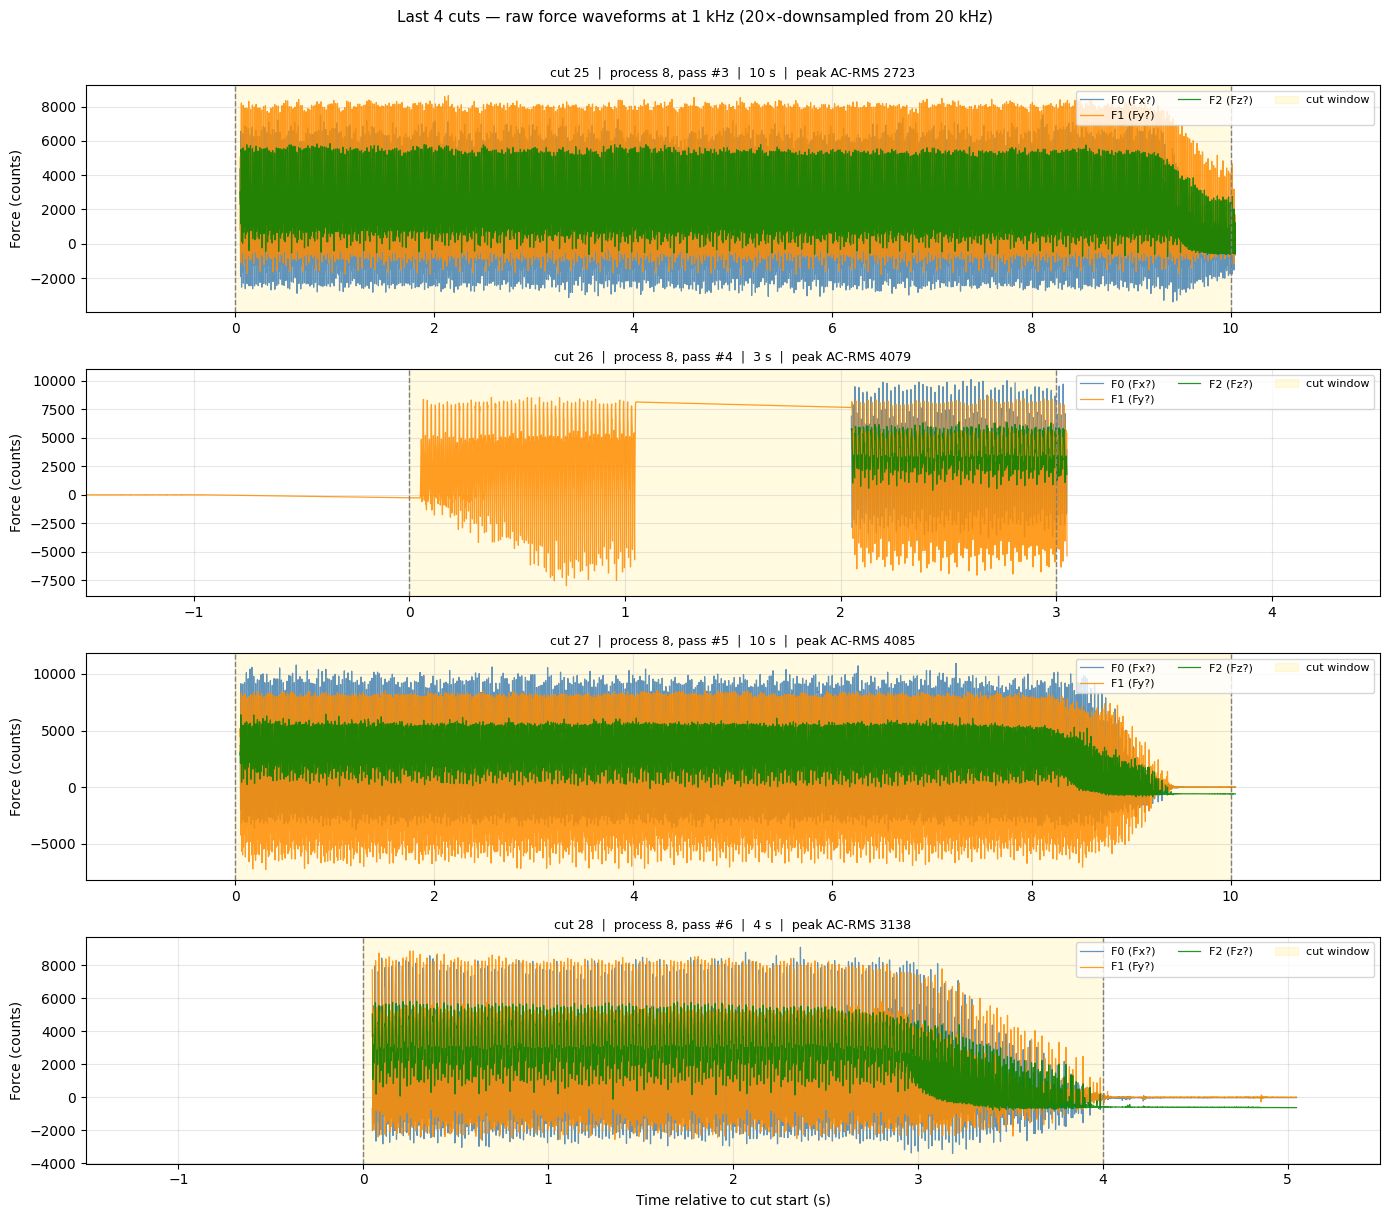

saved lev008_last4_cuts_waveform.png


In [17]:
DISPLAY_SKIP = 20          # 20 kHz → 1 kHz for display
PAD_S        = 1.5         # context padding around each cut (seconds)

last4_cuts = cuts_df.tail(4).reset_index(drop=True)

# load raw sample data for all 3 channels, filtered to the 4-cut time window
t_win_start = last4_cuts["cut_start"].min() - pd.Timedelta(seconds=PAD_S)
t_win_end   = last4_cuts["cut_end"].max()   + pd.Timedelta(seconds=PAD_S)

ch_data = {}
for ch in ["force_0", "force_1", "force_2"]:
    df_raw = pd.read_parquet(OUTPUT_DIR / f"{ch}_lev008_raw.parquet")
    sc = sorted([c for c in df_raw.columns if c.startswith("s") and c[1:].isdigit()])
    df_raw = df_raw.sort_values("time").reset_index(drop=True)
    mask = (df_raw["time"] >= t_win_start) & (df_raw["time"] <= t_win_end)
    ch_data[ch] = df_raw.loc[mask, ["time"] + sc].reset_index(drop=True)
    print(f"  {ch}: {mask.sum()} blocks in window")


def reconstruct_signal(df_ch, sc):
    """Concatenate blocks → (t_ns array, signal array) at full 20 kHz."""
    n_samples = len(sc)
    t_all, y_all = [], []
    for _, blk in df_ch.iterrows():
        block_end_ns = blk["time"].value              # nanoseconds since epoch
        step_ns      = int(1e9 / FS_FORCE)            # 50 000 ns per sample at 20 kHz
        # sample 0 is (n_samples−1) steps before block_end
        t_blk = block_end_ns - np.arange(n_samples - 1, -1, -1, dtype=np.int64) * step_ns
        t_all.append(t_blk)
        y_all.append(blk[sc].to_numpy(dtype=np.float64))
    return np.concatenate(t_all), np.concatenate(y_all)


sc_ref = sorted([c for c in ch_data["force_0"].columns if c.startswith("s") and c[1:].isdigit()])
signals = {ch: reconstruct_signal(ch_data[ch], sc_ref) for ch in ch_data}

# ── plot ─────────────────────────────────────────────────────────────────────
ch_colors  = {"force_0": "steelblue", "force_1": "darkorange", "force_2": "green"}
ch_labels  = {"force_0": "F0 (Fx?)",  "force_1": "F1 (Fy?)",  "force_2": "F2 (Fz?)"}

fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=False)

for ax, (_, row) in zip(axes, last4_cuts.iterrows()):
    cut_start_ns = row["cut_start"].value
    cut_end_ns   = row["cut_end"].value
    pad_ns       = int(PAD_S * 1e9)

    for ch in ["force_0", "force_1", "force_2"]:
        t_ns, y = signals[ch]
        # restrict to padded cut window
        mask = (t_ns >= cut_start_ns - pad_ns) & (t_ns <= cut_end_ns + pad_ns)
        t_s  = (t_ns[mask] - cut_start_ns) / 1e9      # seconds relative to cut start
        y_m  = y[mask]
        ax.plot(t_s[::DISPLAY_SKIP], y_m[::DISPLAY_SKIP],
                lw=0.9, color=ch_colors[ch], label=ch_labels[ch], alpha=0.85)

    # mark the active cut window
    ax.axvspan(0, row["duration_s"], alpha=0.12, color="gold", label="cut window")
    ax.axvline(0,                color="gray", lw=1, ls="--")
    ax.axvline(row["duration_s"], color="gray", lw=1, ls="--")

    pid  = int(row["process_id"])
    cwid = int(row["cut_id_within_process"])
    ax.set_title(
        f"cut {int(row['cut_id'])}  |  process {pid}, pass #{cwid}  |  "
        f"{row['duration_s']:.0f} s  |  peak AC-RMS {row['peak_max_ac']:.0f}",
        fontsize=9,
    )
    ax.set_ylabel("Force (counts)")
    ax.set_xlim(-PAD_S, row["duration_s"] + PAD_S)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8, loc="upper right", ncol=3)

axes[-1].set_xlabel("Time relative to cut start (s)")
plt.suptitle("Last 4 cuts — raw force waveforms at 1 kHz (20×-downsampled from 20 kHz)",
             fontsize=11, y=1.01)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "lev008_last4_cuts_waveform.png", dpi=120, bbox_inches="tight")
plt.show()
print("saved lev008_last4_cuts_waveform.png")

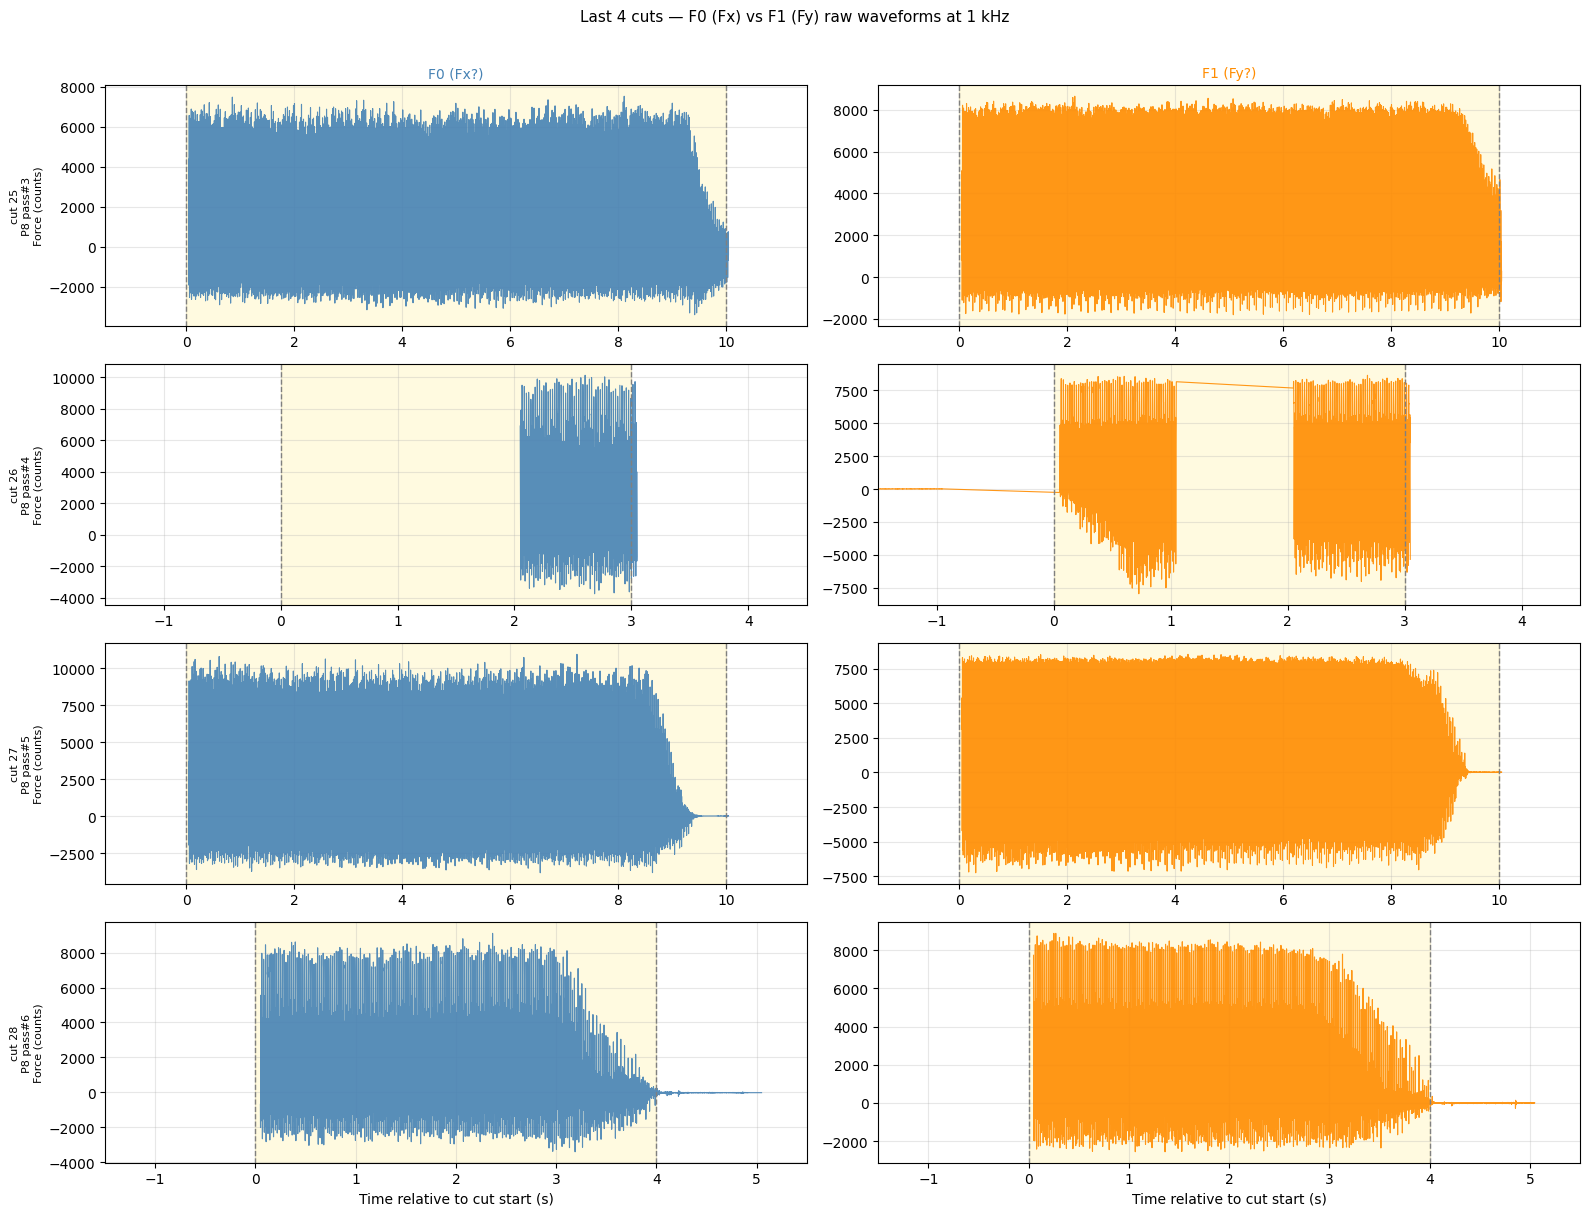

saved lev008_last4_cuts_f0_f1.png


In [18]:
# Same 4-cut window, now split into separate panels per channel (F0 left, F1 right).
# signals and last4_cuts are already built in the cell above.

fig, axes = plt.subplots(4, 2, figsize=(16, 12), sharex=False)
fig.suptitle(
    "Last 4 cuts — F0 (Fx) vs F1 (Fy) raw waveforms at 1 kHz",
    fontsize=11, y=1.01,
)

ch_cfg = [("force_0", "steelblue", "F0 (Fx?)"),
          ("force_1", "darkorange", "F1 (Fy?)")]

for row_idx, (_, cut_row) in enumerate(last4_cuts.iterrows()):
    cut_start_ns = cut_row["cut_start"].value
    pad_ns       = int(PAD_S * 1e9)
    x_lo, x_hi  = -PAD_S, cut_row["duration_s"] + PAD_S

    for col_idx, (ch, color, label) in enumerate(ch_cfg):
        ax = axes[row_idx, col_idx]

        t_ns, y = signals[ch]
        mask = (t_ns >= cut_start_ns - pad_ns) & \
               (t_ns <= cut_start_ns + int((cut_row["duration_s"] + PAD_S) * 1e9))
        t_s = (t_ns[mask] - cut_start_ns) / 1e9
        y_m = y[mask]
        ax.plot(t_s[::DISPLAY_SKIP], y_m[::DISPLAY_SKIP],
                lw=0.8, color=color, alpha=0.9)

        ax.axvspan(0, cut_row["duration_s"], alpha=0.12, color="gold")
        ax.axvline(0,                     color="gray", lw=1, ls="--")
        ax.axvline(cut_row["duration_s"], color="gray", lw=1, ls="--")
        ax.set_xlim(x_lo, x_hi)
        ax.grid(True, alpha=0.3)

        pid  = int(cut_row["process_id"])
        cwid = int(cut_row["cut_id_within_process"])
        if col_idx == 0:
            ax.set_ylabel(f"cut {int(cut_row['cut_id'])}\nP{pid} pass#{cwid}\nForce (counts)",
                          fontsize=8)
        if row_idx == 0:
            ax.set_title(label, fontsize=10, color=color)
        if row_idx == 3:
            ax.set_xlabel("Time relative to cut start (s)")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "lev008_last4_cuts_f0_f1.png", dpi=120, bbox_inches="tight")
plt.show()
print("saved lev008_last4_cuts_f0_f1.png")